# Atividade 3.2 - Matrizes

In [34]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

--- 
## Exercício 5-1: Indexação de Matrizes
**Objetivo:** Criar uma matriz $3 \times 4$ usando `np.arange(12).reshape(3,4)` e extrair o elemento na segunda linha e quarta coluna utilizando indexação flexível (*softcoding*). Imprimir a mensagem "The matrix element at index (2,4) is 7.".

In [35]:
A = np.arange(12).reshape(3, 4)

# Índices na matemática (1-based)
row_math = 2
col_math = 4

# Extração em Python (0-based)
element = A[row_math - 1, col_math - 1]

print(f"The matrix element at index ({row_math},{col_math}) is {element}.")

The matrix element at index (2,4) is 7.


--- 
## Exercícios 5-2 e 5-3: Fatiamento (*Slicing*) e Reorganização de Blocos
**Objetivo:** Criar uma matriz de 10x10 com valores de 0 a 99 (representando a Figura 5-6 original). Extrair os 4 blocos de tamanho $5 \times 5$ e reproduzir as Figuras 5-6 (submatriz) e 5-7 (blocos deslocados) usando visualização.

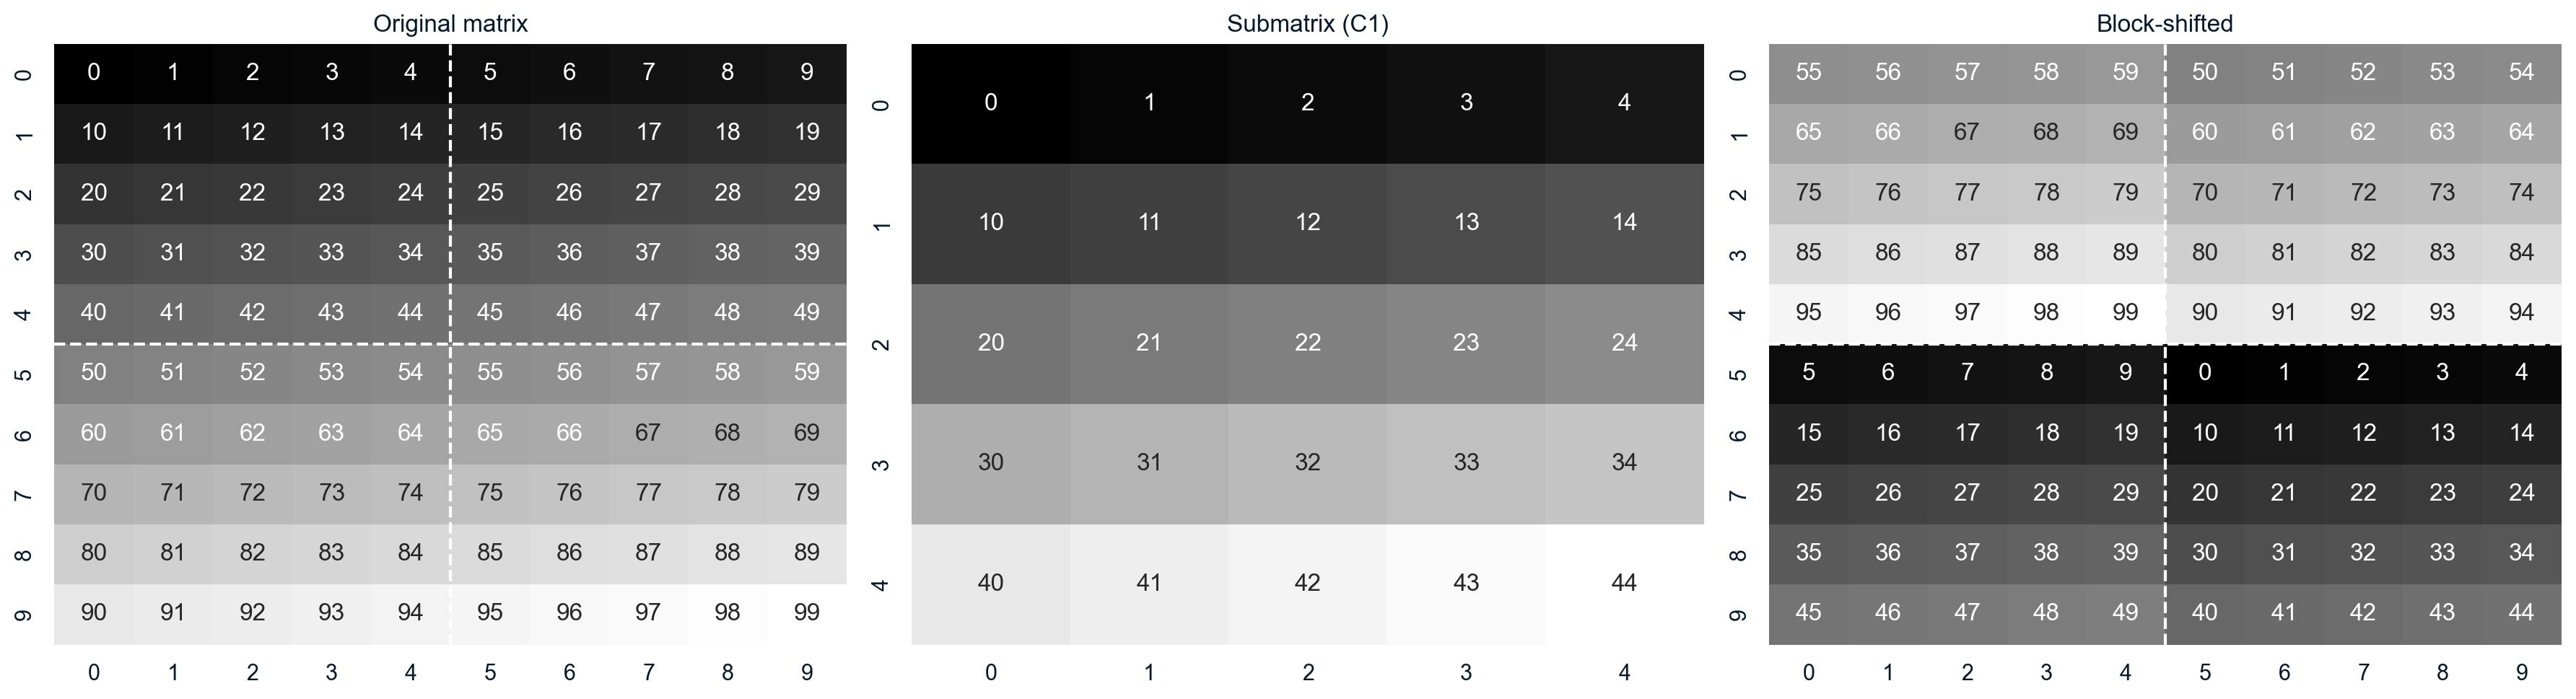

In [36]:
# Criando a Matriz Original (10x10) com valores de 0 a 99
C = np.arange(100).reshape(10, 10)

# Fatiamento em 4 blocos 5x5
C1 = C[:5, :5]   # Top-left (Submatriz pedida no 5-2)
C2 = C[:5, 5:]   # Top-right
C3 = C[5:, :5]   # Bottom-left
C4 = C[5:, 5:]   # Bottom-right

# Reorganizando os blocos conforme a Figura 5-7 (Block-shifted)
C_shifted = np.block([[C4, C3], 
                      [C2, C1]])

# --- Visualização (Seaborn) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(C, annot=True, fmt="d", cmap="gray", cbar=False, ax=axes[0])
axes[0].set_title("Original matrix")
axes[0].axhline(5, color='white', linestyle='--')
axes[0].axvline(5, color='white', linestyle='--')

sns.heatmap(C1, annot=True, fmt="d", cmap="gray", cbar=False, ax=axes[1])
axes[1].set_title("Submatrix (C1)")

sns.heatmap(C_shifted, annot=True, fmt="d", cmap="gray", cbar=False, ax=axes[2])
axes[2].set_title("Block-shifted")
axes[2].axhline(5, color='white', linestyle='--')
axes[2].axvline(5, color='white', linestyle='--')

plt.tight_layout()
plt.show()

--- 
## Exercício 5-4: Adição de Matrizes com Laços `for`
**Objetivo:** Implementar a adição de matrizes usando dois laços `for` para percorrer as linhas e colunas. Demonstrar o que acontece ao tentar somar matrizes de tamanhos incompatíveis.

In [37]:
def add_matrices_loops(A, B):
    if A.shape != B.shape:
        raise ValueError(f"As matrizes têm tamanhos incompatíveis para soma: {A.shape} vs {B.shape}")
    
    rows, cols = A.shape
    C = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            C[i, j] = A[i, j] + B[i, j]
    return C

M1 = np.ones((2, 2))
M2 = np.ones((2, 2)) * 3
print("Soma com laços:\n", add_matrices_loops(M1, M2))

try:
    M_incompativel = np.ones((3, 3))
    add_matrices_loops(M1, M_incompativel)
except Exception as e:
    print("\nExceção capturada ao somar matrizes incompatíveis:", e)

Soma com laços:
 [[4. 4.]
 [4. 4.]]

Exceção capturada ao somar matrizes incompatíveis: As matrizes têm tamanhos incompatíveis para soma: (2, 2) vs (3, 3)


--- 
## Exercício 5-5: Comutatividade e Distributividade Escalar
**Objetivo:** Comprovar as leis $\sigma(A+B) = \sigma A + \sigma B = A\sigma + B\sigma$. Criar matrizes aleatórias $3 \times 4$ e ignorar diferenças residuais de precisão de computação em torno de $10^{-15}$.

In [38]:
np.random.seed(42)
A = np.random.randn(3, 4)
B = np.random.randn(3, 4)
sigma = np.random.randn()

expr1 = sigma * (A + B)
expr2 = (sigma * A) + (sigma * B)
expr3 = (A * sigma) + (B * sigma)

# Comprovando com tolerância (ignorando diferenças em precisão flutuante ~1e-15)
check1 = np.allclose(expr1, expr2, atol=1e-14)
check2 = np.allclose(expr2, expr3, atol=1e-14)

print(f"σ(A + B) == σA + σB : {check1}")
print(f"σA + σB == Aσ + Bσ : {check2}")

σ(A + B) == σA + σB : True
σA + σB == Aσ + Bσ : True


--- 
## Exercício 5-6: Multiplicação Padrão de Matrizes com Laços `for`
**Objetivo:** Escrever a multiplicação matricial do zero através de iterações em laços e conferir com o operador `@` do NumPy.

In [39]:
def dot_matrices_loops(A, B):
    if A.shape[1] != B.shape[0]:
        raise ValueError("Dimensões internas incompatíveis para multiplicação.")
        
    C = np.zeros((A.shape[0], B.shape[1]))
    for i in range(A.shape[0]):          # Linhas de A
        for j in range(B.shape[1]):      # Colunas de B
            for k in range(A.shape[1]):  # Dimensão interna
                C[i, j] += A[i, k] * B[k, j]
    return C

M1 = np.random.randn(2, 3)
M2 = np.random.randn(3, 4)

res_loops = dot_matrices_loops(M1, M2)
res_numpy = M1 @ M2

print("Resultados coincidem?", np.allclose(res_loops, res_numpy))

Resultados coincidem? True


--- 
## Exercício 5-7: Regra LIVE EVIL
**Objetivo:** Testar a regra $(LIVE)^T = E^T V^T I^T L^T$ usando matrizes retangulares $L \in \mathbb{R}^{2 \times 6}$, $I \in \mathbb{R}^{6 \times 3}$, $V \in \mathbb{R}^{3 \times 5}$ e $E \in \mathbb{R}^{5 \times 2}$, comparando as manipulações de matriz transposta na ordem direta e reversa.

In [40]:
L = np.random.randn(2, 6)
I_mat = np.random.randn(6, 3)
V = np.random.randn(3, 5)
E = np.random.randn(5, 2)

# 1. Multiplica as 4 matrizes e depois transpõe
step2_res = (L @ I_mat @ V @ E).T

# 2. Transpõe individualmente e multiplica na MESMA ordem (Vai dar erro dimensional se as dimensões fossem fixadas)
try:
    step3_res = L.T @ I_mat.T @ V.T @ E.T
except Exception as err:
    print("Step 3 falhou como esperado (erro de dimensão interna):", err)

# 3. Transpõe individualmente e inverte a ordem (LIVE EVIL)
step4_res = E.T @ V.T @ I_mat.T @ L.T

print("A Regra (LIVE)^T == E^T V^T I^T L^T é verdadeira?", np.allclose(step2_res, step4_res))

Step 3 falhou como esperado (erro de dimensão interna): matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)
A Regra (LIVE)^T == E^T V^T I^T L^T é verdadeira? True


--- 
## Exercícios 5-8 e 5-9: Verificação e Criação de Matrizes Simétricas
**Objetivo 5-8:** Escrever uma função que verifique a simetria de uma matriz, verificando se ela é quadrada e aplicando uma tolerância razoável aos erros computacionais.

**Objetivo 5-9:** Implementar o método aditivo $(A + A^T)/2$ a partir de uma matriz não-simétrica e testá-lo usando a função do exercício 5-8.

In [41]:
def is_symmetric(M, tol=1e-8):
    if M.shape[0] != M.shape[1]:
        return False  # Matrizes simétricas precisam ser quadradas
    return np.allclose(M, M.T, atol=tol)

A = np.random.randn(4, 4)
print("A matriz aleatória 'A' é simétrica?", is_symmetric(A))

# Exercício 5-9: Método aditivo
A_sym = (A + A.T) / 2
print("A matriz 'A_sym = (A + A.T)/2' é simétrica?", is_symmetric(A_sym))

A matriz aleatória 'A' é simétrica? False
A matriz 'A_sym = (A + A.T)/2' é simétrica? True


--- 
## Exercício 5-10: Combinação Linear através de Matriz-Vetor
**Objetivo:** Computar combinações lineares $\sigma_1 v_1 + \sigma_2 v_2$ utilizando o princípio da multiplicação de matriz por vetor, consolidando a matriz como colunas ($As$).

*(Nota: Assumindo dois vetores arbitrários em $\mathbb{R}^3$ e dois pesos escalares)*.

In [42]:
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
sigma1, sigma2 = 2.0, -1.0

# Método 1: Somatório linear com vetores e escalares
metodo_linear = (sigma1 * v1) + (sigma2 * v2)

# Método 2: Matriz multiplicada pelo vetor coluna com escalares
A = np.column_stack((v1, v2))      # Forma uma matriz 3x2
s_vec = np.array([sigma1, sigma2]) # Vetor coluna dos escalares 2x1
metodo_matriz = A @ s_vec

print("Método Escalar-Vetor :", metodo_linear)
print("Método Matriz-Vetor  :", metodo_matriz)

Método Escalar-Vetor : [-2. -1.  0.]
Método Matriz-Vetor  : [-2. -1.  0.]


--- 
## Exercícios 5-11 e 5-12: Propriedades das Matrizes Diagonais
**Objetivo 5-11:** Demonstrar que pré-multiplicar por matriz diagonal escala as linhas, e pós-multiplicar escala as colunas de uma matriz. Computar a "tabela de multiplicação" com matrizes de raízes quadradas.

**Objetivo 5-12:** Demonstrar e ilustrar em código que multiplicar duas matrizes diagonais (padrão `@`) é identico à multiplicação de Hadamard (`*`).

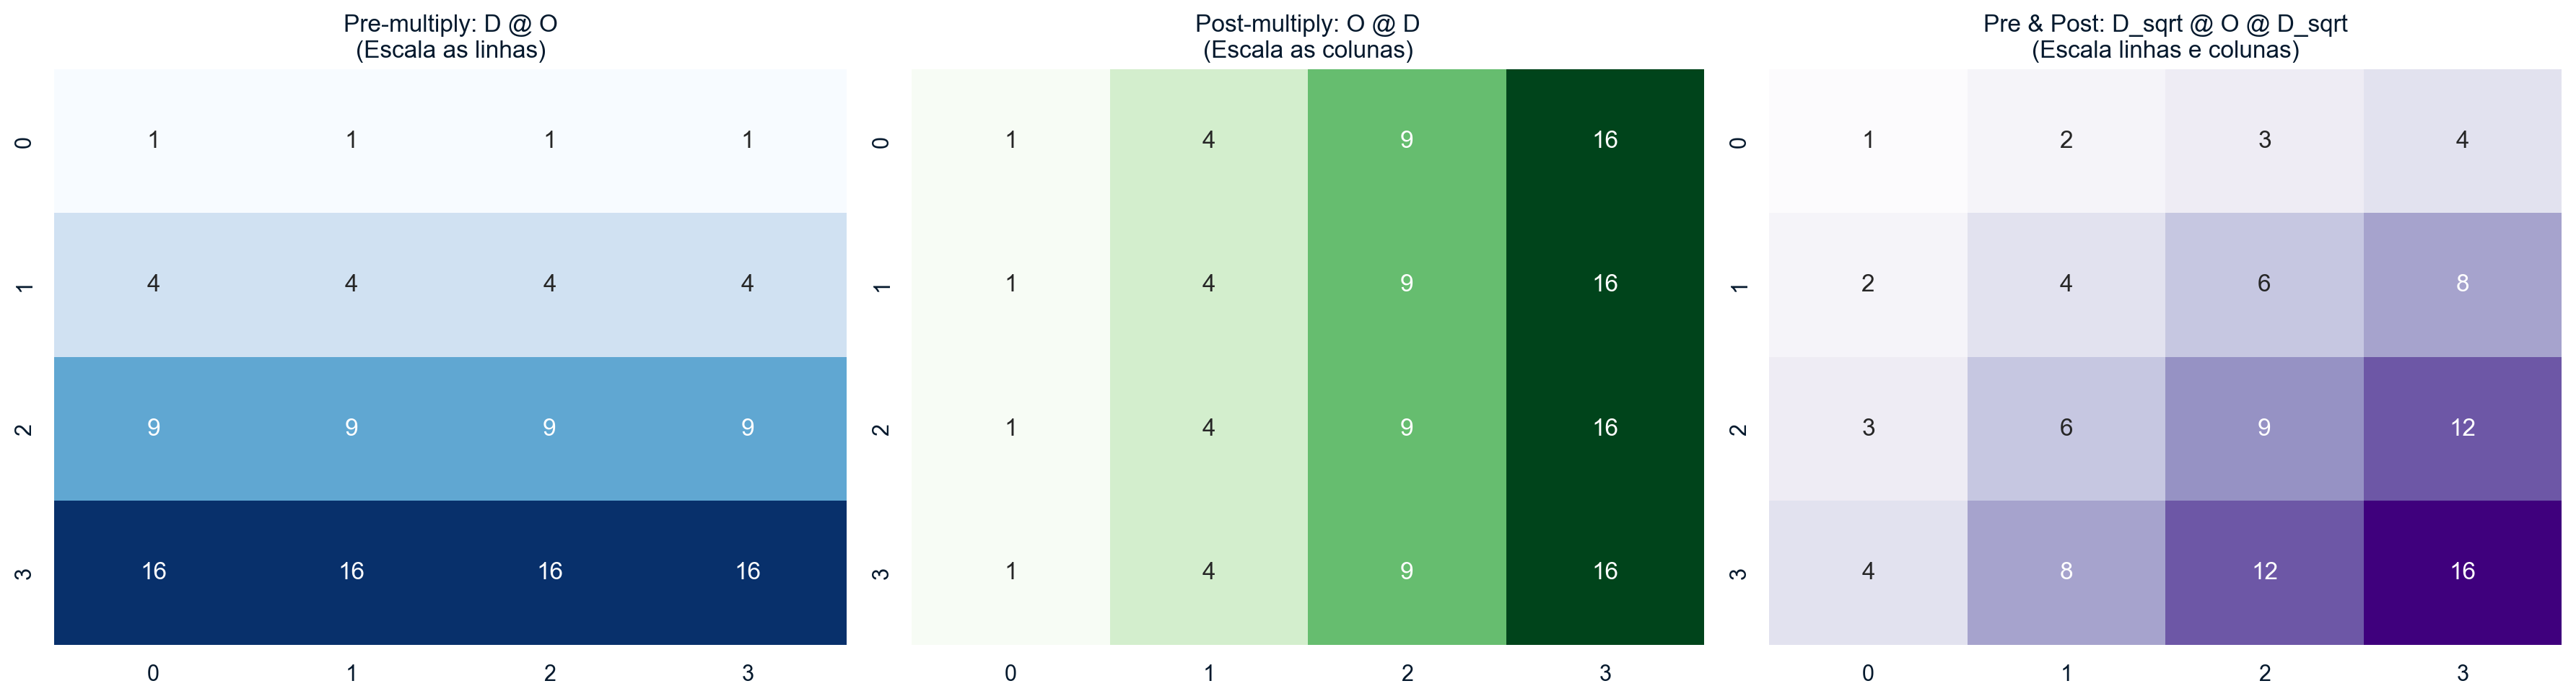

(D1 @ D2) é igual a (D1 * D2) para matrizes diagonais? True


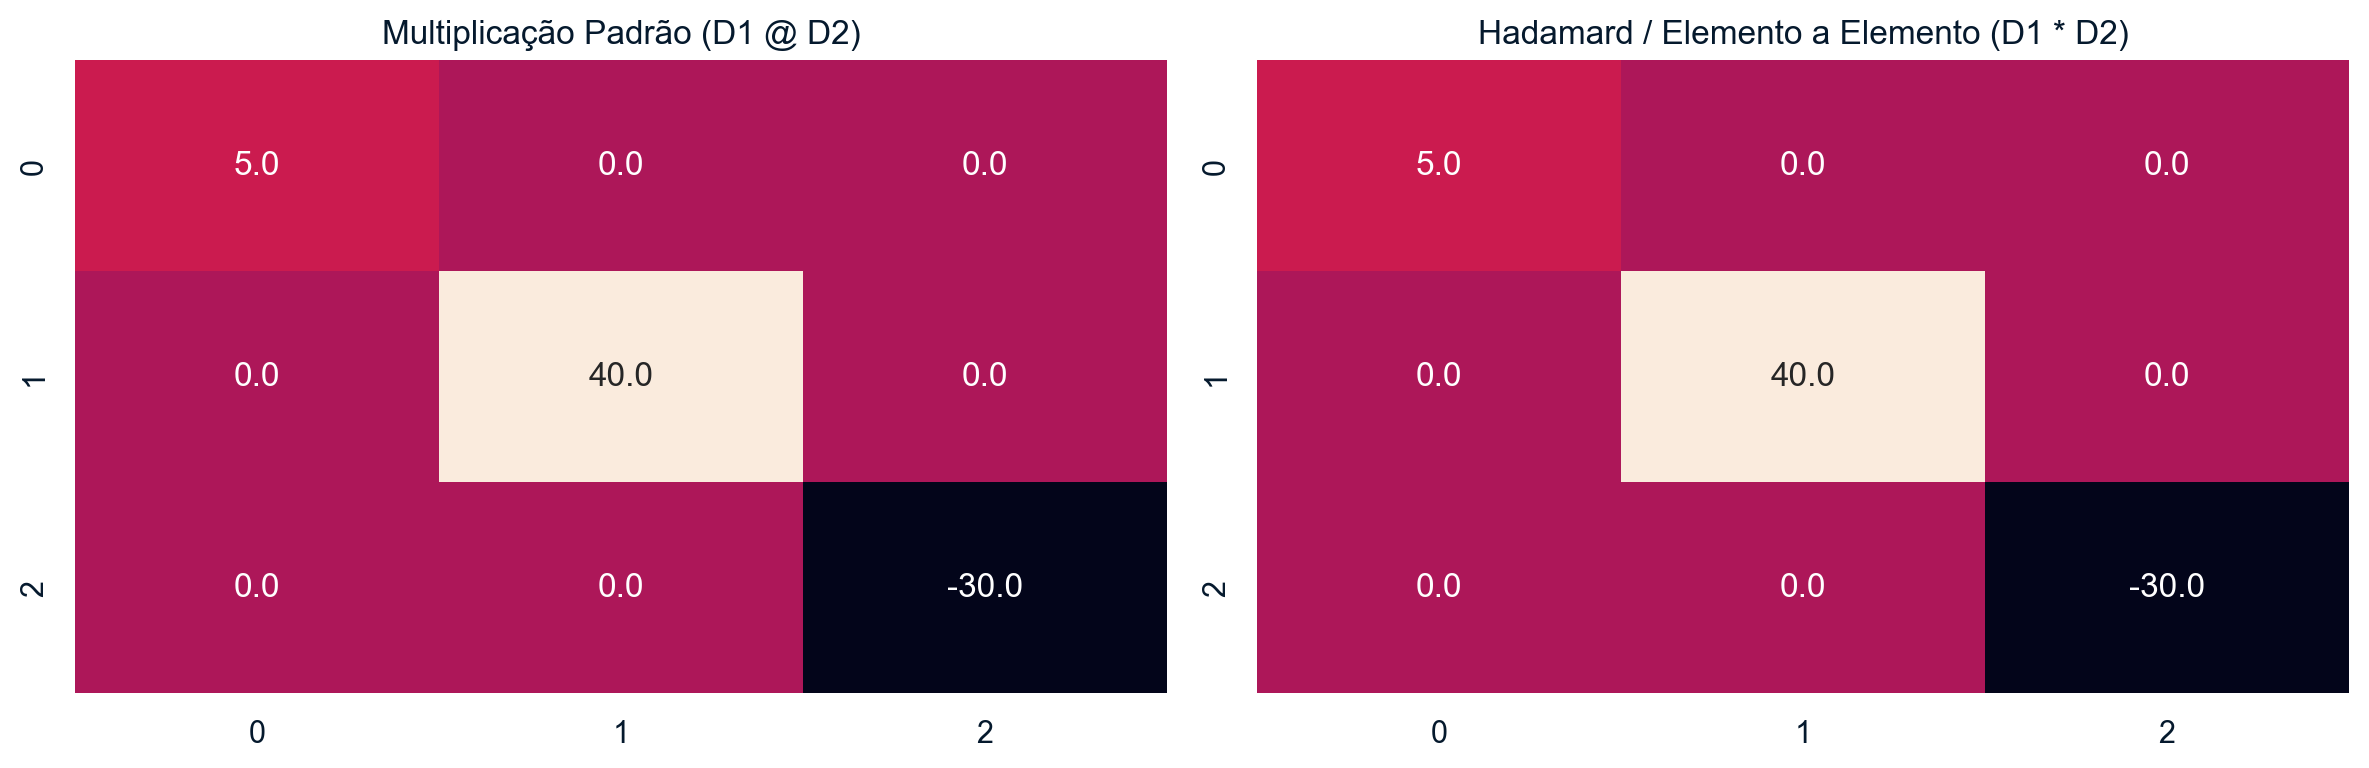

In [45]:
# === Exercício 5-11 ===
O = np.ones((4, 4))
D = np.diag([1, 4, 9, 16])
D_sqrt = np.diag([1, 2, 3, 4])

pre_mult = D @ O
post_mult = O @ D
pre_post_mult = D_sqrt @ O @ D_sqrt

# Visualização com Seaborn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(pre_mult, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Pre-multiply: D @ O\n(Escala as linhas)")

sns.heatmap(post_mult, annot=True, fmt=".0f", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Post-multiply: O @ D\n(Escala as colunas)")

sns.heatmap(pre_post_mult, annot=True, fmt=".0f", cmap="Purples", cbar=False, ax=axes[2])
axes[2].set_title("Pre & Post: D_sqrt @ O @ D_sqrt\n(Escala linhas e colunas)")

plt.tight_layout()
plt.show()

# === Exercício 5-12 ===
D1 = np.diag([10, 20, 30])
D2 = np.diag([0.5, 2, -1])

res_matmul = D1 @ D2
res_hadamard = D1 * D2

print("(D1 @ D2) é igual a (D1 * D2) para matrizes diagonais?", np.allclose(res_matmul, res_hadamard))

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(res_matmul, annot=True, fmt=".1f", cmap="rocket", cbar=False, ax=axes2[0])
axes2[0].set_title("Multiplicação Padrão (D1 @ D2)")

sns.heatmap(res_hadamard, annot=True, fmt=".1f", cmap="rocket", cbar=False, ax=axes2[1])
axes2[1].set_title("Hadamard / Elemento a Elemento (D1 * D2)")

plt.tight_layout()
plt.show()